In [1]:
from skimage.io import imread
import os
from skimage.transform import resize

In [2]:
path='/content/drive/MyDrive/Data'
subpath=os.listdir(path)
data=[]
target=[]
for sub in subpath:
  subfolder=os.path.join(path,sub)
  images=os.listdir(subfolder)
  #print(images)
  for img in images:
    img_path=os.path.join(subfolder,img)
    img_array=imread(img_path)
    #print(img_path)
    image_resized=resize(img_array,(200,200,3))
    data.append(image_resized.flatten())
    target.append(subpath.index(sub))
print(target)



[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [4]:
len(target)

126

In [6]:
import numpy as np
x=np.array(data)
y=np.array(target)

In [19]:
x.shape

(126, 120000)

In [7]:
from sklearn.model_selection import train_test_split
x_tr,x_te,y_tr,y_te=train_test_split(x,y,test_size=0.20,random_state=11)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
models=[KNeighborsClassifier(),RandomForestClassifier(random_state=11),AdaBoostClassifier(random_state=11),GaussianNB()]
for model in models:
  model.fit(x_tr,y_tr)
  y_pred=model.predict(x_te)
  print(obj,'\n',classification_report(y_te,y_pred))

KNeighborsClassifier() 
               precision    recall  f1-score   support

           0       0.62      0.71      0.67        14
           1       0.60      0.50      0.55        12

    accuracy                           0.62        26
   macro avg       0.61      0.61      0.61        26
weighted avg       0.61      0.62      0.61        26

RandomForestClassifier(random_state=11) 
               precision    recall  f1-score   support

           0       0.50      0.57      0.53        14
           1       0.40      0.33      0.36        12

    accuracy                           0.46        26
   macro avg       0.45      0.45      0.45        26
weighted avg       0.45      0.46      0.46        26

AdaBoostClassifier(random_state=11) 
               precision    recall  f1-score   support

           0       0.45      0.36      0.40        14
           1       0.40      0.50      0.44        12

    accuracy                           0.42        26
   macro avg       0.43

In [10]:
knn=KNeighborsClassifier()
knn.fit(x_tr,y_tr)

KNeighborsClassifier()

array([[[ 79,  90,  92],
        [ 78,  89,  91],
        [ 72,  83,  85],
        ...,
        [ 58,  45,  28],
        [ 59,  43,  27],
        [ 57,  41,  25]],

       [[ 94, 105, 107],
        [ 90, 101, 103],
        [ 76,  87,  89],
        ...,
        [ 57,  44,  27],
        [ 58,  42,  26],
        [ 56,  40,  24]],

       [[100, 111, 113],
        [ 96, 107, 109],
        [ 74,  85,  87],
        ...,
        [ 55,  42,  23],
        [ 56,  40,  24],
        [ 55,  39,  23]],

       ...,

       [[ 74,  43,  22],
        [ 72,  41,  20],
        [ 73,  43,  19],
        ...,
        [ 75,  44,  15],
        [ 75,  44,  15],
        [ 74,  43,  14]],

       [[ 73,  42,  21],
        [ 71,  40,  19],
        [ 73,  43,  19],
        ...,
        [ 79,  48,  19],
        [ 78,  47,  18],
        [ 77,  46,  17]],

       [[ 72,  41,  20],
        [ 70,  39,  18],
        [ 71,  41,  17],
        ...,
        [ 82,  51,  22],
        [ 81,  50,  21],
        [ 79,  48,  19]]], dtype=uint8)
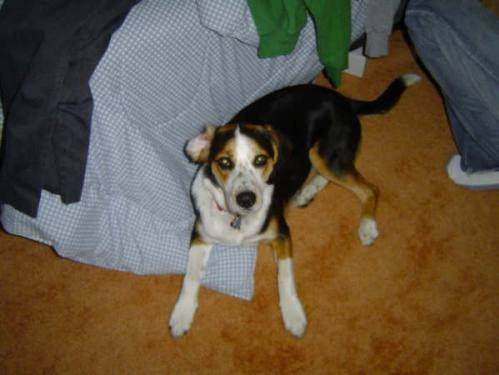

In [20]:

img_resized.shape

(200, 200, 3)

In [23]:

y_pred

array([0])

In [24]:
subpath[0]

'Dog'

In [30]:
def predictor(link):
  img=imread(link)
  img_resized=resize(img,(200,200,3))
  img_flatten=img_resized.flatten()
  img_reshape=img_flatten.reshape(1,-1)
  y_pred=knn.predict(img_reshape)
  value=y_pred.item()
  print(subpath[value])



In [31]:
predictor('/content/drive/MyDrive/Data/Dog/dog.27.jpg')

Dog
